In [37]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

In [38]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [39]:
%%R

require('tidyverse')
require('tidycensus')

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: tidyverse
Loading required package: tidycensus


## 311 call complaints about dog waste in NYC

### January - March 2025

In [23]:
df_2025 = pd.read_csv('311_dog_waste_2025.csv')

In [24]:
df_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 952 entries, 0 to 951
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unique Key                      952 non-null    int64  
 1   Created Date                    952 non-null    object 
 2   Closed Date                     939 non-null    object 
 3   Agency                          952 non-null    object 
 4   Agency Name                     952 non-null    object 
 5   Complaint Type                  952 non-null    object 
 6   Descriptor                      952 non-null    object 
 7   Location Type                   952 non-null    object 
 8   Incident Zip                    952 non-null    int64  
 9   Incident Address                952 non-null    object 
 10  Street Name                     952 non-null    object 
 11  Cross Street 1                  952 non-null    object 
 12  Cross Street 2                  951 

In [31]:
pd.set_option('display.max_rows', None)
df_2025['Community Board'].value_counts()

Community Board
12 MANHATTAN             154
08 BRONX                  32
05 BROOKLYN               32
14 QUEENS                 32
01 STATEN ISLAND          30
12 QUEENS                 29
12 BRONX                  27
14 BROOKLYN               27
07 MANHATTAN              25
03 BROOKLYN               24
17 BROOKLYN               23
09 BRONX                  23
04 BRONX                  20
10 MANHATTAN              20
13 QUEENS                 19
01 BRONX                  18
15 BROOKLYN               18
07 BRONX                  18
06 BROOKLYN               17
05 BRONX                  16
08 BROOKLYN               16
10 QUEENS                 16
03 STATEN ISLAND          16
06 BRONX                  15
09 QUEENS                 15
12 BROOKLYN               14
04 MANHATTAN              13
18 BROOKLYN               12
02 BROOKLYN               12
09 BROOKLYN               11
03 BRONX                  11
05 QUEENS                 11
04 BROOKLYN               10
11 BRONX                  1

**--> The most affected area is Manhattan Community Board 12, which includes Inwood and Washington Heights**

In [35]:
df_2025['Community Board'].nunique()

63

**--> In 2025, there are complaints from every community district (59 districts + 4 unspecified).**

In [59]:
df_2025[df_2025['Community Board'] == '12 MANHATTAN']['Incident Zip'].value_counts()

Incident Zip
10032    139
10034      7
10033      5
10040      3
Name: count, dtype: int64

In [77]:
df_2025[df_2025['Community Board'] == '12 MANHATTAN']['Location'].value_counts()

Location
(40.83733075391628, -73.94656853762118)     59
(40.83561762599567, -73.9456520072136)      30
(40.836139402067694, -73.946251477162)      21
(40.835829046904706, -73.94581807002287)     7
(40.83665290918615, -73.94678229977103)      3
(40.83588396825875, -73.9458758463922)       3
(40.86655695619762, -73.92753844657459)      3
(40.83501085696898, -73.94525498804433)      3
(40.83415704524157, -73.94482204361711)      3
(40.83417240875407, -73.9483634819345)       2
(40.84946194268086, -73.93034750725323)      1
(40.862154299661306, -73.9272829458812)      1
(40.845936271792255, -73.9324945174274)      1
(40.843817041132596, -73.9367795540281)      1
(40.86748111447652, -73.92626838632344)      1
(40.85123189856867, -73.93940035890009)      1
(40.851476554612354, -73.94012306917718)     1
(40.83722808926937, -73.94422320443937)      1
(40.849412465935345, -73.93022827878026)     1
(40.8639261347363, -73.92971051889944)       1
(40.868075970452765, -73.92511436036561)     1
(40.

In [78]:
df_2025[(df_2025['Community Board'] == '12 MANHATTAN') & 
        (df_2025['Location'] == '(40.83733075391628, -73.94656853762118)')]

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
9,63605500,01/02/2025 09:55:04 PM,01/03/2025 08:52:09 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
22,63661108,01/06/2025 08:44:53 AM,01/07/2025 12:06:59 AM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
34,63664508,01/07/2025 08:40:47 AM,01/08/2025 12:32:00 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
39,63673803,01/07/2025 06:42:06 PM,01/08/2025 12:32:04 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
42,63684835,01/08/2025 08:42:35 AM,01/08/2025 12:32:08 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
48,63678494,01/08/2025 06:26:12 PM,01/09/2025 01:28:32 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
56,63695325,01/09/2025 05:50:43 PM,01/10/2025 01:21:49 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
58,63714043,01/10/2025 08:35:08 AM,01/10/2025 01:21:53 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
65,63714130,01/10/2025 07:52:02 PM,01/11/2025 08:51:41 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"
66,63720087,01/10/2025 08:05:23 PM,01/11/2025 08:51:47 PM,DSNY,Department of Sanitation,Dirty Condition,Dog Waste,Sidewalk,10032,884 RIVERSIDE DRIVE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.837331,-73.946569,"(40.83733075391628, -73.94656853762118)"


In [63]:
# !pip install folium


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [64]:
import pandas as pd
import folium
from folium.plugins import HeatMap
import ast

# Assuming df_2025 is your DataFrame and it already exists
# Create a subset of the data for Community Board 12 in Manhattan
cb12_data = df_2025[df_2025['Community Board'] == '12 MANHATTAN']

# Get the location value counts
location_counts = cb12_data['Location'].value_counts()

# Convert the location_counts Series to a DataFrame
# The index contains the location strings like "(40.837, -73.946)"
map_data = []

for location_str, count in location_counts.items():
    # Parse the location string into coordinates
    # Convert string representation of tuple to actual coordinates
    try:
        # If the location is already a tuple
        if isinstance(location_str, tuple):
            lat, lon = location_str
        # If the location is a string representation of a tuple
        else:
            # Remove parentheses and split by comma
            coords = location_str.strip('()').split(',')
            lat = float(coords[0].strip())
            lon = float(coords[1].strip())
        
        map_data.append({'lat': lat, 'lon': lon, 'count': count})
    except:
        # Skip invalid locations
        continue

# Create a DataFrame from the parsed data
map_df = pd.DataFrame(map_data)

# Create a base map centered at the mean of coordinates
center_lat = map_df['lat'].mean()
center_lon = map_df['lon'].mean()
mymap = folium.Map(location=[center_lat, center_lon], zoom_start=14)

# Get max count for scaling
max_count = map_df['count'].max()

# Add circle markers with size and color based on count
for idx, row in map_df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=max(5, row['count']/3),  # Adjust divisor as needed
        popup=f"Count: {row['count']}",
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=min(0.2 + (row['count'] / max_count) * 0.8, 0.95),
        opacity=0.8
    ).add_to(mymap)

# Add heatmap layer
heat_data = [[row['lat'], row['lon'], row['count']] for idx, row in map_df.iterrows()]
HeatMap(heat_data).add_to(mymap)

# Save the map
mymap.save('manhattan_cb12_heatmap.html')

# If in a Jupyter notebook, display the map
display(mymap)

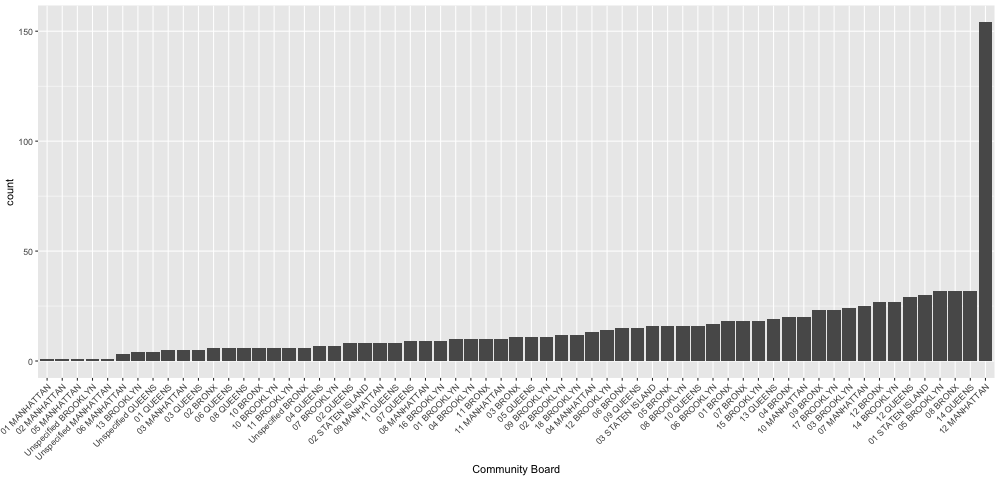

In [54]:
%%R -i df_2025 -w 1000
# Count the frequencies
counts <- as.data.frame(table(df_2025$`Community Board`))
names(counts) <- c("Community_Board", "Freq")

# Sort the counts
counts <- counts[order(counts$Freq),]

# Convert to factor with ordered levels
df_2025$`Community Board` <- factor(df_2025$`Community Board`, 
                                   levels = counts$Community_Board)

# Now plot with the ordered factor
ggplot(df_2025, aes(x=`Community Board`)) +
    geom_bar() +
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

### January - March 2024

In [27]:
df_2024 = pd.read_csv('311_dog_waste_2024.csv')

In [28]:
df_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 788 entries, 0 to 787
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unique Key                      788 non-null    int64  
 1   Created Date                    788 non-null    object 
 2   Closed Date                     788 non-null    object 
 3   Agency                          788 non-null    object 
 4   Agency Name                     788 non-null    object 
 5   Complaint Type                  788 non-null    object 
 6   Descriptor                      788 non-null    object 
 7   Location Type                   788 non-null    object 
 8   Incident Zip                    786 non-null    float64
 9   Incident Address                788 non-null    object 
 10  Street Name                     788 non-null    object 
 11  Cross Street 1                  785 non-null    object 
 12  Cross Street 2                  785 

In [30]:
pd.set_option('display.max_rows', None)
df_2024['Community Board'].value_counts()

Community Board
12 QUEENS                    39
07 BRONX                     30
05 BROOKLYN                  29
01 QUEENS                    23
01 BROOKLYN                  23
11 MANHATTAN                 20
05 QUEENS                    20
03 STATEN ISLAND             20
17 BROOKLYN                  19
12 BRONX                     19
09 BRONX                     19
01 STATEN ISLAND             19
06 BRONX                     17
07 BROOKLYN                  17
07 QUEENS                    16
12 MANHATTAN                 16
13 QUEENS                    16
03 BROOKLYN                  16
10 QUEENS                    15
18 BROOKLYN                  15
14 BROOKLYN                  15
09 MANHATTAN                 15
10 MANHATTAN                 14
02 QUEENS                    13
09 BROOKLYN                  13
03 BRONX                     13
15 BROOKLYN                  13
02 STATEN ISLAND             12
02 BROOKLYN                  12
08 BRONX                     12
14 QUEENS               

In [55]:
952-788

164

In [32]:
# percent increase from the same period in 2024 to 2025
(952-788)/788

0.20812182741116753

In [34]:
df_2024['Community Board'].nunique()

63

**--> In 2024, there were complaints from every community district (59 districts + 4 unspecified).**

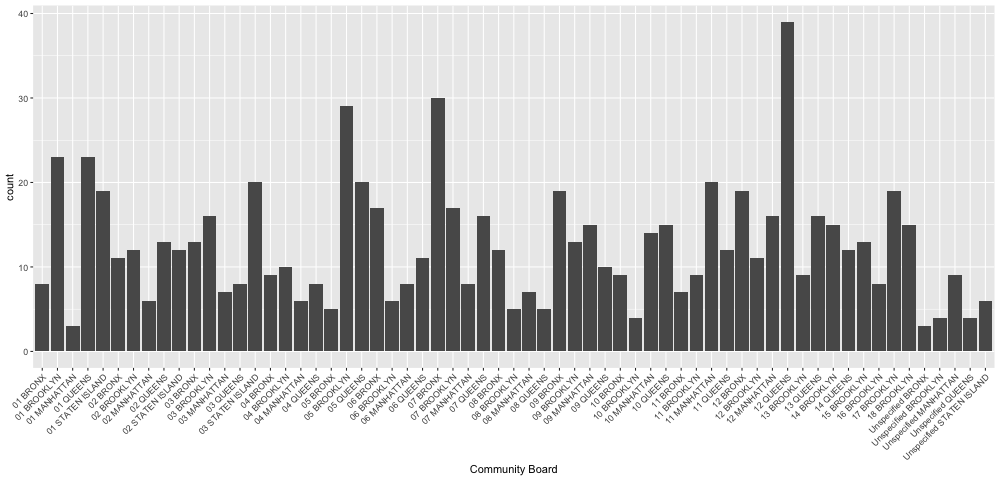

In [48]:
%%R -i df_2024 -w 1000

ggplot(df_2024, aes(x=`Community Board`)) +
    geom_bar() +
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

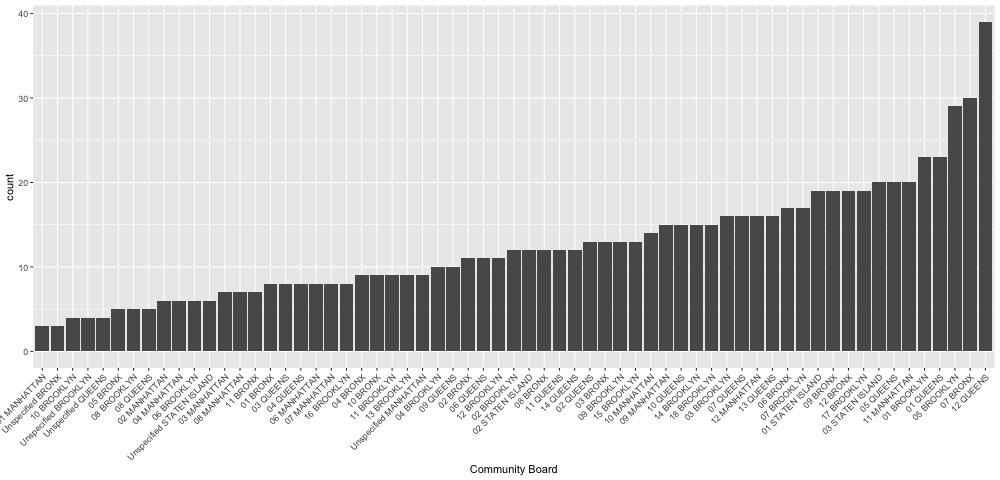

In [53]:
%%R -i df_2024 -w 1000
# Count the frequencies
counts <- as.data.frame(table(df_2024$`Community Board`))
names(counts) <- c("Community_Board", "Freq")

# Sort the counts
counts <- counts[order(counts$Freq),]

# Convert to factor with ordered levels
df_2024$`Community Board` <- factor(df_2024$`Community Board`, 
                                   levels = counts$Community_Board)

# Now plot with the ordered factor
ggplot(df_2024, aes(x=`Community Board`)) +
    geom_bar() +
    theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))